In [2]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

Загрузка данных

In [3]:

df = pd.read_csv('../../data/children_products/clildren_product_cleaned.csv')

print(f"Размер исходного датасета: {df.shape}")
print(f"Первые строки:")
df.head()

Размер исходного датасета: (610913, 16)
Первые строки:


,Дата,НомерЗаказаНаСайте,МетодДоставки,Группа2,Группа3,Тип,Отменено,Количество,Цена,Статус,Гео,Маржа,СуммаУслуг,Телефон_new,ID_SKU,МетодДоставки_Групп
0,2017-03-01 11:41:00,3998972_TR,Курьерская,КРУПНОГАБАРИТНЫЙ ТОВАР,КОЛЯСКИ,КГТ,Нет,1,680.0,Возврат,Москва,508.00,0,55574854-48574951555577,ID9010020114553,Курьерская
1,2017-03-01 12:22:00,3999117_TR,Магазины,"ТЕКСТИЛЬ, ТРИКОТАЖ",ОДЕЖДА ДЛЯ НОВОРОЖДЕННЫХ (0-2 лет),ОДЕЖДА,Нет,1,379.0,Доставлен,Регионы,169.20,0,55575453-56535648535679,IDL00028974351,Магазины
2,2017-03-01 12:31:00,3999122_TR,Магазины,ИГРУШКИ,ИГРУШКИ ДЛЯ ДЕВОЧЕК,ИГРУШКИ,Нет,1,3325.0,Доставлен,Регионы,2176.00,0,55574950-57515657535772,IDL00038573351,Магазины
3,2017-03-01 03:06:00,3999363_TR,Курьерская,"ТЕКСТИЛЬ, ТРИКОТАЖ",ОДЕЖДА ДЛЯ НОВОРОЖДЕННЫХ (0-2 лет),ОДЕЖДА,Нет,1,330.0,Доставлен,Москва,163.04,0,55574851-55545249535475,IDL00034303856,Курьерская
4,2017-03-01 11:38:00,3999411_TR,Магазины,ИГРУШКИ,ИГРУШКИ ДЛЯ РАЗВИТИЯ МАЛЫШЕЙ,ИГРУШКИ,Нет,1,199.0,Доставлен,Регионы,120.00,0,55574854-56495552515179,IDL00035791553,Магазины


In [4]:
df.info()
print("Уникальные значения статуса:")
print(df['Статус'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610913 entries, 0 to 610912
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Дата                 610913 non-null  object 
 1   НомерЗаказаНаСайте   610913 non-null  object 
 2   МетодДоставки        610913 non-null  object 
 3   Группа2              610913 non-null  object 
 4   Группа3              610913 non-null  object 
 5   Тип                  610913 non-null  object 
 6   Отменено             610913 non-null  object 
 7   Количество           610913 non-null  int64  
 8   Цена                 610913 non-null  float64
 9   Статус               610913 non-null  object 
 10  Гео                  610913 non-null  object 
 11  Маржа                610913 non-null  float64
 12  СуммаУслуг           610913 non-null  int64  
 13  Телефон_new          610913 non-null  object 
 14  ID_SKU               610913 non-null  object 
 15  МетодДоставки_Гру

In [5]:
df_filtered = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()

print(f"Размер после фильтрации (только 'Доставлен'): {df_filtered.shape}")
print(f"Удалено записей: {len(df) - len(df_filtered)}")

Размер после фильтрации (только 'Доставлен'): (420857, 16)
Удалено записей: 190056


In [6]:
print(df_filtered[['Телефон_new', 'ID_SKU', 'Дата']].isnull().sum())

df_filtered = df_filtered.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
print(f"Размер после удаления пропусков: {df_filtered.shape}")

Телефон_new    0
ID_SKU         0
Дата           0
dtype: int64
Размер после удаления пропусков: (420857, 16)


In [7]:
df_filtered['Дата'] = pd.to_datetime(df_filtered['Дата'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Дата'])
print(f"Диапазон дат: {df_filtered['Дата'].min()} - {df_filtered['Дата'].max()}")
print(f"Размер после обработки дат: {df_filtered.shape}")

Диапазон дат: 2017-03-01 00:03:00 - 2017-04-30 23:58:00
Размер после обработки дат: (420857, 16)


In [9]:
# Фильтрация редких пользователей и товаров (минимум 3 покупки)
MIN_INTERACTIONS = 3


user_counts = df_filtered.groupby('Телефон_new').size()
item_counts = df_filtered.groupby('ID_SKU').size()
active_users = user_counts[user_counts >= MIN_INTERACTIONS].index
active_items = item_counts[item_counts >= MIN_INTERACTIONS].index
before = len(df_filtered)
df_filtered = df_filtered[
    df_filtered['Телефон_new'].isin(active_users) &
    df_filtered['ID_SKU'].isin(active_items)
]

n_users = df_filtered['Телефон_new'].nunique()
n_items = df_filtered['ID_SKU'].nunique()
n_interactions = len(df_filtered)
density = n_interactions / (n_users * n_items) * 100
print(f"После фильтрации (≥{MIN_INTERACTIONS} покупок):")
print(f"Пользователей: {n_users:,}, Товаров: {n_items:,}")
print(f"Взаимодействий: {n_interactions:,}")
print(f"Плотность матрицы: {density:.4f}%")

После фильтрации (≥3 покупок):
Пользователей: 31,923, Товаров: 19,038
Взаимодействий: 304,274
Плотность матрицы: 0.0501%


Статистика покупок на пользователя:
count    31923.000000
mean         9.531498
std         10.830846
min          1.000000
25%          4.000000
50%          6.000000
75%         11.000000
max        227.000000
dtype: float64


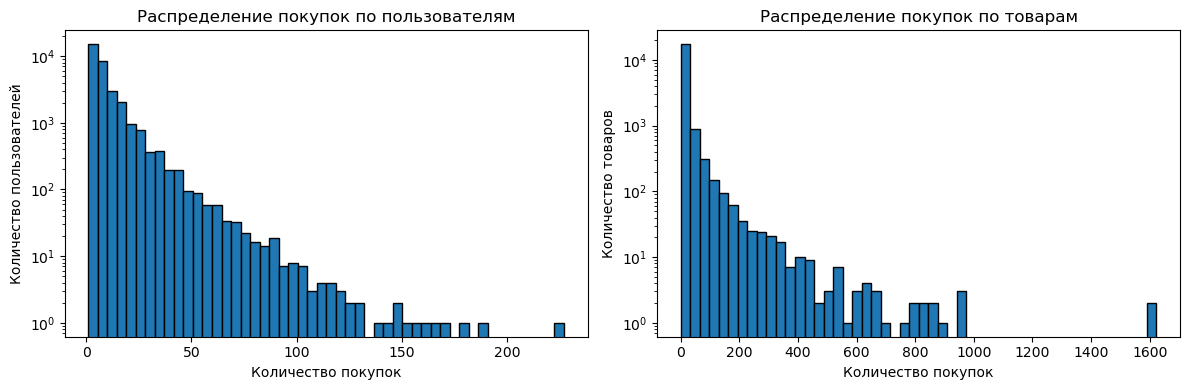

In [10]:
# Распределение количества покупок по пользователям
user_purchases = df_filtered.groupby('Телефон_new').size()

print("Статистика покупок на пользователя:")
print(user_purchases.describe())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(user_purchases, bins=50, edgecolor='black')
plt.xlabel('Количество покупок')
plt.ylabel('Количество пользователей')
plt.title('Распределение покупок по пользователям')
plt.yscale('log')

plt.subplot(1, 2, 2)
item_purchases = df_filtered.groupby('ID_SKU').size()
plt.hist(item_purchases, bins=50, edgecolor='black')
plt.xlabel('Количество покупок')
plt.ylabel('Количество товаров')
plt.title('Распределение покупок по товарам')
plt.yscale('log')

plt.tight_layout()
plt.show()

Подготовка для ALS

In [11]:
interactions = df_filtered.groupby(['Телефон_new', 'ID_SKU']).size().reset_index(name='count')

print(f"Количество уникальных пар (пользователь, товар): {len(interactions):,}")
print(f"Среднее количество покупок одного товара пользователем: {interactions['count'].mean():.2f}")
interactions.head()

Количество уникальных пар (пользователь, товар): 277,256
Среднее количество покупок одного товара пользователем: 1.10


,Телефон_new,ID_SKU,count
0,32555749-545749525150 .,ID000sn-5681048,1
1,32555749-545749525150 .,ID110000017654,1
2,32555749-545749525150 .,ID110000017755,1
3,32555749-545749525150 .,ID110000017856,1
4,32555749-545749525150 .,ID9010001872856,1


In [12]:
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

interactions['user_id'] = user_encoder.fit_transform(interactions['Телефон_new'])
interactions['item_id'] = item_encoder.fit_transform(interactions['ID_SKU'])

user_id_to_phone = dict(zip(interactions['user_id'], interactions['Телефон_new']))
item_id_to_sku = dict(zip(interactions['item_id'], interactions['ID_SKU']))

interactions.head()

,Телефон_new,ID_SKU,count,user_id,item_id
0,32555749-545749525150 .,ID000sn-5681048,1,0,1000
1,32555749-545749525150 .,ID110000017654,1,0,2716
2,32555749-545749525150 .,ID110000017755,1,0,2717
3,32555749-545749525150 .,ID110000017856,1,0,2718
4,32555749-545749525150 .,ID9010001872856,1,0,3757


In [13]:
interactions_with_date = df_filtered.merge(
    interactions[['Телефон_new', 'ID_SKU', 'user_id', 'item_id', 'count']],
    on=['Телефон_new', 'ID_SKU'],
    how='inner'
)
interactions_with_date = interactions_with_date.sort_values('Дата')
print(f"Размер данных с датами: {len(interactions_with_date):,}")
interactions_with_date.head()

Размер данных с датами: 304,274


,Дата,НомерЗаказаНаСайте,МетодДоставки,Группа2,Группа3,Тип,Отменено,Количество,Цена,Статус,Гео,Маржа,СуммаУслуг,Телефон_new,ID_SKU,МетодДоставки_Групп,user_id,item_id,count
5692,2017-03-01 00:03:00,3998915_TR,Магазины,ПОДГУЗНИКИ,ПОДГУЗНИКИ,ППКП,Нет,1,1180.0,Доставлен,Москва,55.77,0,55574953-49564948565473,ID9010017103553,Магазины,9339,4656,1
5691,2017-03-01 00:03:00,3998915_TR,Магазины,ПОДГУЗНИКИ,ПОДГУЗНИКИ,ППКП,Нет,1,1129.0,Доставлен,Москва,4.77,0,55574953-49564948565473,ID9010017103654,Магазины,9339,4657,1
66106,2017-03-01 00:03:00,3998903_TR,Магазины,ДЕТСКОЕ ПИТАНИЕ,ЗАМЕНИТЕЛИ МОЛОКА,ППКП,Нет,1,1135.0,Доставлен,Москва,48.54,0,55575054-54494955515772,ID10022021048,Магазины,21735,2701,2
66049,2017-03-01 00:03:00,3998903_TR,Магазины,ДЕТСКОЕ ПИТАНИЕ,КАШИ,ППКП,Нет,1,389.0,Доставлен,Москва,63.92,0,55575054-54494955515772,IDL00027735452,Магазины,21735,9951,1
17625,2017-03-01 00:03:00,3998903_TR,Магазины,ИГРУШКИ,ИГРУШКИ ДЛЯ РАЗВИТИЯ МАЛЫШЕЙ,ИГРУШКИ,Нет,1,107.0,Доставлен,Москва,26.95,0,55575054-54494955515772,ID10019982149,Магазины,21735,2617,1


In [14]:
split_date = interactions_with_date['Дата'].quantile(0.7)

print(f"Дата разделения: {split_date}")
print(f"Train: до {split_date}")
print(f"Test: после {split_date}")

train_data = interactions_with_date[interactions_with_date['Дата'] < split_date].copy()
test_data = interactions_with_date[interactions_with_date['Дата'] >= split_date].copy()

print(f"Размер train: {len(train_data):,} ({len(train_data)/len(interactions_with_date)*100:.1f}%)")
print(f"Размер test: {len(test_data):,} ({len(test_data)/len(interactions_with_date)*100:.1f}%)")

Дата разделения: 2017-04-12 02:09:00
Train: до 2017-04-12 02:09:00
Test: после 2017-04-12 02:09:00
Размер train: 212,638 (69.9%)
Размер test: 91,636 (30.1%)


In [15]:
train_interactions = train_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()

test_interactions = test_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()

print(f"Уникальных взаимодействий в train: {len(train_interactions):,}")
print(f"Уникальных взаимодействий в test: {len(test_interactions):,}")

test_users = set(test_interactions['user_id'].unique())
test_items = set(test_interactions['item_id'].unique())
train_users = set(train_interactions['user_id'].unique())
train_items = set(train_interactions['item_id'].unique())

print(f"Пользователей в train: {len(train_users):,}")
print(f"Пользователей в test: {len(test_users):,}")
print(f"Пользователей только в test (cold start): {len(test_users - train_users):,}")
print(f"Товаров в train: {len(train_items):,}")
print(f"Товаров в test: {len(test_items):,}")
print(f"Товаров только в test (cold start): {len(test_items - train_items):,}")

Уникальных взаимодействий в train: 197,222
Уникальных взаимодействий в test: 88,744
Пользователей в train: 25,436
Пользователей в test: 14,020
Пользователей только в test (cold start): 6,487
Товаров в train: 17,973
Товаров в test: 14,981
Товаров только в test (cold start): 1,065


In [16]:
def create_sparse_matrix(interactions_df, n_users, n_items):
    sparse_matrix = csr_matrix(
        (interactions_df['count'].values,
         (interactions_df['user_id'].values, interactions_df['item_id'].values)),
        shape=(n_users, n_items)
    )
    return sparse_matrix

n_users = len(user_encoder.classes_)
n_items = len(item_encoder.classes_)

train_matrix = create_sparse_matrix(train_interactions, n_users, n_items)
test_matrix = create_sparse_matrix(test_interactions, n_users, n_items)

print(f"Размер train матрицы: {train_matrix.shape}")
print(f"Ненулевых элементов в train: {train_matrix.nnz:,}")
print(f"Плотность train матрицы: {train_matrix.nnz / (n_users * n_items) * 100:.4f}%")
print(f"Размер test матрицы: {test_matrix.shape}")
print(f"Ненулевых элементов в test: {test_matrix.nnz:,}")

Размер train матрицы: (31923, 19038)
Ненулевых элементов в train: 197,222
Плотность train матрицы: 0.0325%
Размер test матрицы: (31923, 19038)
Ненулевых элементов в test: 88,744


Обучаем модель

In [17]:
model = AlternatingLeastSquares(
    factors=50,
    regularization=0.01,
    iterations=15,
    calculate_training_loss=True,
    random_state=42
)

/opt/homebrew/Caskroom/miniconda/base/envs/data_analysis/lib/python3.11/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 12 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


In [18]:
model.fit(train_matrix)

  0%|          | 0/15 [00:00<?, ?it/s]

In [20]:
def get_recommendations(model, user_id, train_matrix, k=10, filter_already_liked=True):
    recommendations = model.recommend(
        user_id,
        train_matrix[user_id],
        N=k,
        filter_already_liked_items=filter_already_liked
    )
    item_ids, scores = recommendations
    
    return list(item_ids), list(scores)

test_user_id = 0
rec_items, rec_scores = get_recommendations(model, test_user_id, train_matrix, k=5)

for item_id, score in zip(rec_items, rec_scores):
    print(f"Товар {item_id} (SKU: {item_id_to_sku.get(item_id, 'N/A')}): {score:.4f}")

Товар 9061 (SKU: IDL00024550856): 0.0033
Товар 9076 (SKU: IDL00024554553): 0.0018
Товар 9059 (SKU: IDL00024550351): 0.0017
Товар 14478 (SKU: IDL00036858351): 0.0017
Товар 9073 (SKU: IDL00024554048): 0.0016


In [21]:
def precision_at_k(recommended_items, relevant_items, k):
    recommended_k = set(recommended_items[:k])
    relevant = set(relevant_items)
    if len(recommended_k) == 0:
        return 0.0
    
    return len(recommended_k & relevant) / len(recommended_k)

def recall_at_k(recommended_items, relevant_items, k):
    recommended_k = set(recommended_items[:k])
    relevant = set(relevant_items)
    
    if len(relevant) == 0:
        return 0.0
    
    return len(recommended_k & relevant) / len(relevant)

def map_at_k(recommended_items, relevant_items, k):
    relevant = set(relevant_items)
    
    if len(relevant) == 0:
        return 0.0
    
    score = 0.0
    num_hits = 0.0
    
    for i, item in enumerate(recommended_items[:k]):
        if item in relevant:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
    
    return score / min(len(relevant), k)

def ndcg_at_k(recommended_items, relevant_items, k):
    relevant = set(relevant_items)
    
    if len(relevant) == 0:
        return 0.0
    
    dcg = 0.0
    for i, item in enumerate(recommended_items[:k]):
        if item in relevant:
            dcg += 1.0 / np.log2(i + 2)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

Оценка моделей

In [24]:
def evaluate_model(model, train_matrix, test_interactions, k_values=[5, 10, 20]):
    """
    Оценка модели на тестовых данных
    """
    test_user_items = test_interactions.groupby('user_id')['item_id'].apply(list).to_dict()
    
    train_users = set(np.where(train_matrix.getnnz(axis=1) > 0)[0])
    test_users = [u for u in test_user_items.keys() if u in train_users]
    
    results = {k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []} for k in k_values}
    
    for user_id in test_users:
        try:
            rec_items, _ = get_recommendations(
                model, user_id, train_matrix,
                k=max(k_values), filter_already_liked=True
            )
            
            relevant_items = test_user_items[user_id]
            
            for k in k_values:
                results[k]['precision'].append(precision_at_k(rec_items, relevant_items, k))
                results[k]['recall'].append(recall_at_k(rec_items, relevant_items, k))
                results[k]['map'].append(map_at_k(rec_items, relevant_items, k))
                results[k]['ndcg'].append(ndcg_at_k(rec_items, relevant_items, k))
        except Exception as e:
            continue

    avg_results = {}
    for k in k_values:
        avg_results[k] = {
            'precision': np.mean(results[k]['precision']),
            'recall': np.mean(results[k]['recall']),
            'map': np.mean(results[k]['map']),
            'ndcg': np.mean(results[k]['ndcg'])
        }
    
    return avg_results

In [25]:
# Оценка модели
k_values = [5, 10, 20]
results = evaluate_model(model, train_matrix, test_interactions, k_values=k_values)

for k in k_values:
    print(f"\nМетрики для K={k}:")
    print(f"  Precision@{k}: {results[k]['precision']:.4f}")
    print(f"  Recall@{k}:    {results[k]['recall']:.4f}")
    print(f"  MAP@{k}:       {results[k]['map']:.4f}")
    print(f"  NDCG@{k}:      {results[k]['ndcg']:.4f}")



Метрики для K=5:
  Precision@5: 0.0350
  Recall@5:    0.0354
  MAP@5:       0.0306
  NDCG@5:      0.0473

Метрики для K=10:
  Precision@10: 0.0263
  Recall@10:    0.0502
  MAP@10:       0.0277
  NDCG@10:      0.0485

Метрики для K=20:
  Precision@20: 0.0190
  Recall@20:    0.0677
  MAP@20:       0.0273
  NDCG@20:      0.0526


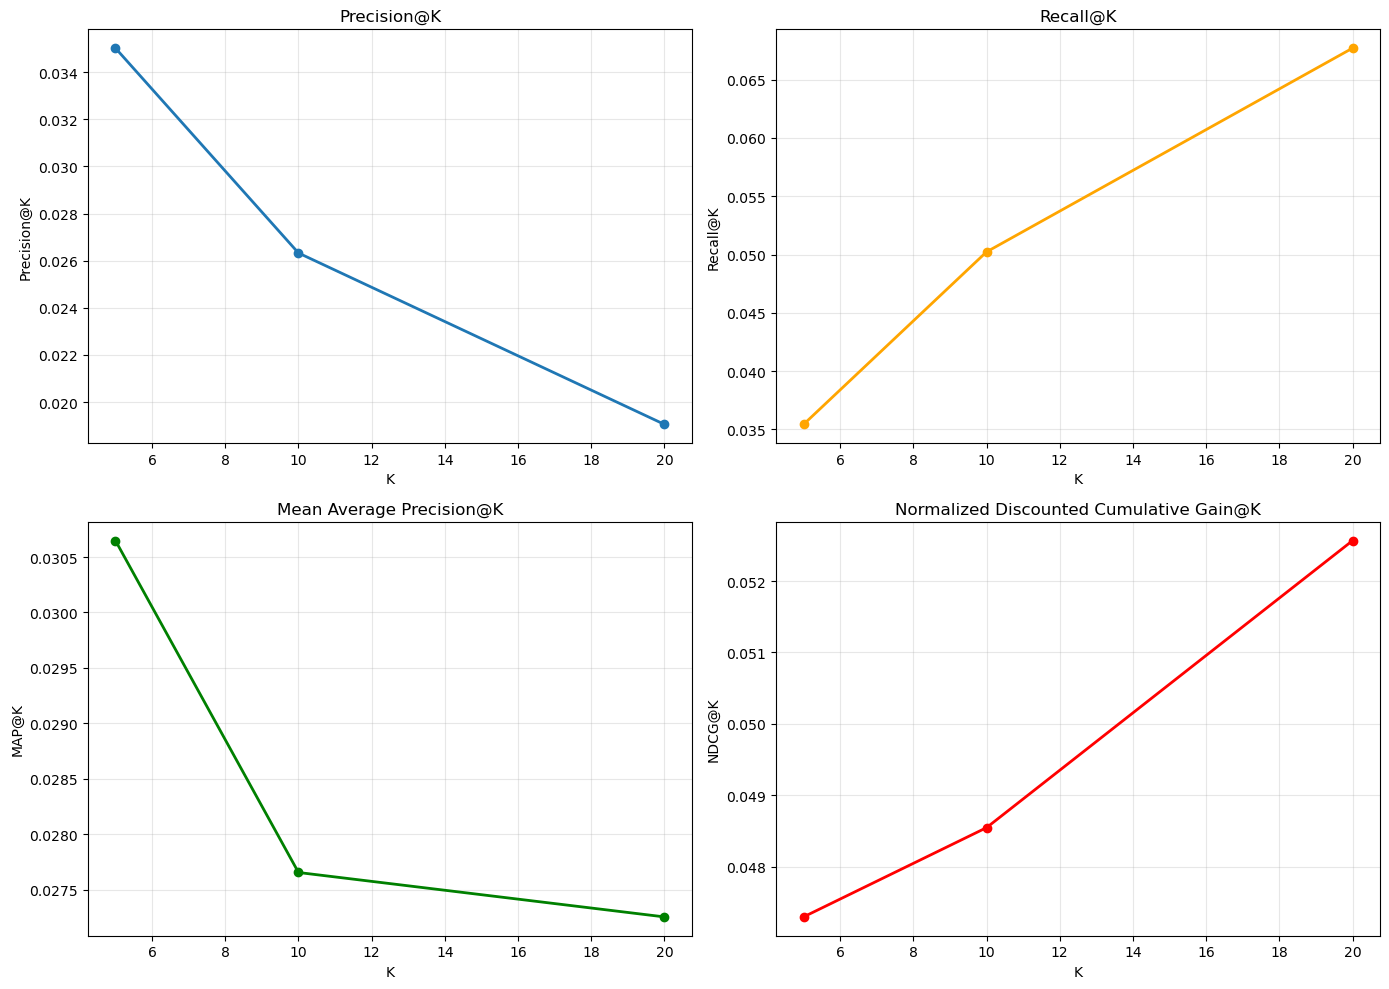

In [26]:

metrics_df = pd.DataFrame(results).T
metrics_df.index.name = 'K'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Precision
axes[0, 0].plot(metrics_df.index, metrics_df['precision'], marker='o', linewidth=2)
axes[0, 0].set_xlabel('K')
axes[0, 0].set_ylabel('Precision@K')
axes[0, 0].set_title('Precision@K')
axes[0, 0].grid(True, alpha=0.3)

# Recall
axes[0, 1].plot(metrics_df.index, metrics_df['recall'], marker='o', linewidth=2, color='orange')
axes[0, 1].set_xlabel('K')
axes[0, 1].set_ylabel('Recall@K')
axes[0, 1].set_title('Recall@K')
axes[0, 1].grid(True, alpha=0.3)

# MAP
axes[1, 0].plot(metrics_df.index, metrics_df['map'], marker='o', linewidth=2, color='green')
axes[1, 0].set_xlabel('K')
axes[1, 0].set_ylabel('MAP@K')
axes[1, 0].set_title('Mean Average Precision@K')
axes[1, 0].grid(True, alpha=0.3)

# NDCG
axes[1, 1].plot(metrics_df.index, metrics_df['ndcg'], marker='o', linewidth=2, color='red')
axes[1, 1].set_xlabel('K')
axes[1, 1].set_ylabel('NDCG@K')
axes[1, 1].set_title('Normalized Discounted Cumulative Gain@K')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()